In [2]:
import os
import matlab.engine  # the matlab engine for python

# import cv2
import numpy as np
from pathlib import Path
from diffcurve.plot_utils import plot_images, remove_frame
import matplotlib.pyplot as plt
from diffcurve.fdct2d.curvelet_2d import get_curvelet_system
from diffcurve.utils import get_project_root
from diffcurve.fdct2d.jax_frontend import jax_fdct_2d, jax_ifdct_2d
from diffcurve.fdct2d.numpy_frontend import perform_ifft2
import scipy
import matplotlib as mpl

import jax
import dLux.utils as dlu

jax.config.update("jax_enable_x64", True)

2025-04-16 10:21:09.553769: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Sample image

In [ ]:
lena_img = scipy.datasets.ascent() / 255.0
lena_img = dlu.downsample(lena_img, 4)

plt.figure(figsize=(4, 3))
plt.imshow(lena_img, cmap="gray")
plt.colorbar()
plt.show()

## Get the curvelet system

In [ ]:
dct_kwargs = {
    "is_real": 0.0,  # complex-valued curvelets
    "finest": 2.0,  # use wavelets at the finest level
    "nbscales": 4.0,
    "nbangles_coarse": 8.0,
    "allcurvelets": False,
}


curvelet_system, curvelet_coeff_dim = get_curvelet_system(
    lena_img.shape[0], lena_img.shape[1], dct_kwargs
)

curvelet_support_size = np.prod(np.array(curvelet_coeff_dim), 1)

## Show a curvelet

In [ ]:
# curvelet_idx = 2

for curvelet_idx in range(curvelet_system.shape[0]):

    fig, axes = plt.subplots(1, 2)

    c = axes[0].imshow((curvelet_system[curvelet_idx]).real, cmap="gray")
    axes[0].set_title("freq")
    # fig.colorbar(c, ax=axes[0])

    axes[1].imshow(perform_ifft2(curvelet_system[curvelet_idx]).real, cmap="gray")
    axes[1].set_title("spatial")

    plt.show()

## Run the curvelet transform and its inverse

In [ ]:
coeff = jax_fdct_2d(lena_img, curvelet_system)

decomp = jax_ifdct_2d(coeff, curvelet_system, curvelet_support_size)

In [ ]:
coeff.shape

## Show some curvelet coeffs

In [ ]:
num_curvelets_to_show = 25


curvelets_coeff_to_show = [
    coeff[curvelet_idx].real.T for curvelet_idx in range(num_curvelets_to_show)
]


im, axes = plot_images(
    curvelets_coeff_to_show,
    nrows=5,
    ncols=5,
    vrange="individual",
    cbar="none",
    cmap="gray",
    fig_size=(6, 6),
)

[remove_frame(ax) for ax in axes.flatten()]

plt.show()

## Show some weighted curvelets

In [ ]:
num_curvelets_to_show = 25

weighted_curvelets_to_show = [
    decomp[curvelet_idx].real.T for curvelet_idx in range(num_curvelets_to_show)
]


im, axes = plot_images(
    weighted_curvelets_to_show,
    nrows=5,
    ncols=5,
    vrange="individual",
    cbar="none",
    cmap="gray",
    fig_size=(6, 6),
)

[remove_frame(ax) for ax in axes.flatten()]

plt.show()

## Show the reconstructed image

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].imshow(lena_img, cmap="gray")
axes[0].set_title("input")

axes[1].imshow(decomp.sum(0).real, cmap="gray")
axes[1].set_title("recon")

mse = np.mean((decomp.sum(0).real - lena_img) ** 2)
c2 = axes[2].imshow(
    np.abs(decomp.sum(0).real - lena_img),
    cmap="seismic",
    norm=mpl.colors.CenteredNorm(),
)
axes[2].set_title(f"|recon - input|")
fig.colorbar(c2, ax=axes[2])


[remove_frame(ax) for ax in axes.flatten()]

print(f"MSE = { mse}")

# `curvelets` package

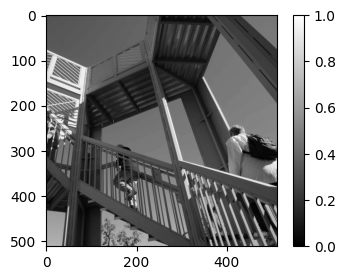

In [5]:
lena_img = scipy.datasets.ascent() / 255.0
# lena_img = dlu.downsample(lena_img, 2)

plt.figure(figsize=(4, 3))
plt.imshow(lena_img, cmap="gray")
plt.colorbar()
plt.show()

In [16]:
import numpy as np
from curvelets.numpy import SimpleUDCT

x = lena_img
C = SimpleUDCT(shape=x.shape, nscales=5)
y = C.forward(x)
# np.testing.assert_allclose(x, C.backward(y))

In [17]:
from jax import tree_util

tree = y
print(tree_util.tree_structure(tree))

PyTreeDef([[[*]], [[*, *, *], [*, *, *]], [[*, *, *, *, *, *], [*, *, *, *, *, *]], [[*, *, *, *, *, *, *, *, *, *, *, *], [*, *, *, *, *, *, *, *, *, *, *, *]], [[*, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *], [*, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *, *]]])


In [18]:
for scale in y:
    for angle in scale:
        for position in angle:
            print(position.shape)

(64, 64)
(32, 32)
(32, 32)
(32, 32)
(32, 32)
(32, 32)
(32, 32)
(64, 32)
(64, 32)
(64, 32)
(64, 32)
(64, 32)
(64, 32)
(32, 64)
(32, 64)
(32, 64)
(32, 64)
(32, 64)
(32, 64)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(128, 32)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(32, 128)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(256, 32)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
(32, 256)
